<a href="https://colab.research.google.com/github/Riyajha182005/project/blob/main/RELIABLITY_MODEL_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
os.listdir("/content")


['.config', 'Test_1_run_1.mat', 'sample_data']

In [ ]:
from scipy.io import loadmat
data = loadmat("/content/Test_1_run_1.mat")
data.keys()


dict_keys(['__header__', '__version__', '__globals__', 'measurement'])

In [ ]:
type(data['measurement'])


numpy.ndarray

In [ ]:
data['measurement'].shape

(1, 1)

In [ ]:
data['measurement'].dtype


dtype([('pwmTempControllerState', 'O'), ('transient', 'O'), ('steadyState', 'O')])

In [ ]:
data['measurement']['pwmTempControllerState'][0][0].shape


(1, 136)

In [ ]:
data['measurement']['transient'][0][0].dtype

dtype([('date', 'O'), ('nanosec_time', 'O'), ('timeEpoch', 'O'), ('timeDomain', 'O')])

In [ ]:
data['measurement']['transient'][0][0]['nanosec_time'].shape

(1, 916)

In [ ]:
data['measurement']['transient'][0][0]['nanosec_time'][:10]

array([[array([[0.26803589]]), array([[0.5770359]]),
        array([[0.97803593]]), array([[0.38003588]]),
        array([[0.77603579]]), array([[0.17603588]]),
        array([[0.57603598]]), array([[0.97603559]]),
        array([[0.38003588]]), array([[0.77903557]]),
        array([[0.17603588]]), array([[0.57603598]]),
        array([[0.97603559]]), array([[0.37803554]]),
        array([[0.77803564]]), array([[0.17603588]]),
        array([[0.57603598]]), array([[0.97603559]]),
        array([[0.37803554]]), array([[0.77703571]]),
        array([[0.17703581]]), array([[0.57603598]]),
        array([[0.97503567]]), array([[0.37803554]]),
        array([[0.77703571]]), array([[0.17603588]]),
        array([[0.57603598]]), array([[0.97603559]]),
        array([[0.37803554]]), array([[0.77603579]]),
        array([[0.17403555]]), array([[0.58103561]]),
        array([[0.97403574]]), array([[0.37603569]]),
        array([[0.77803564]]), array([[0.17603588]]),
        array([[0.57503557]])

**Data Cleaning**

In [ ]:
transient = data['measurement']['transient'][0][0]

In [ ]:
transient.dtype

dtype([('date', 'O'), ('nanosec_time', 'O'), ('timeEpoch', 'O'), ('timeDomain', 'O')])

In [ ]:
data['measurement']['pwmTempControllerState'][0][0].dtype

dtype([('time', 'O'), ('timeEpoch', 'O'), ('nanosec_time', 'O'), ('lowTemp', 'O'), ('highTemp', 'O'), ('shutdownTemp', 'O'), ('gateVoltage', 'O'), ('supplyVoltage', 'O'), ('switchingFrequency', 'O'), ('dutyCycle', 'O'), ('gateState', 'O')])

In [ ]:
data['measurement']['pwmTempControllerState'][0][0]['supplyVoltage']

array([[array([[2]], dtype=uint8), array([[2]], dtype=uint8),
        array([[5]], dtype=uint8), array([[5]], dtype=uint8),
        array([[5]], dtype=uint8), array([[5]], dtype=uint8),
        array([[5]], dtype=uint8), array([[5]], dtype=uint8),
        array([[5]], dtype=uint8), array([[5]], dtype=uint8),
        array([[5]], dtype=uint8), array([[5]], dtype=uint8),
        array([[5]], dtype=uint8), array([[5]], dtype=uint8),
        array([[5]], dtype=uint8), array([[5]], dtype=uint8),
        array([[5]], dtype=uint8), array([[5]], dtype=uint8),
        array([[5]], dtype=uint8), array([[5]], dtype=uint8),
        array([[5]], dtype=uint8), array([[5]], dtype=uint8),
        array([[5]], dtype=uint8), array([[5]], dtype=uint8),
        array([[5]], dtype=uint8), array([[5]], dtype=uint8),
        array([[5]], dtype=uint8), array([[5]], dtype=uint8),
        array([[5]], dtype=uint8), array([[5]], dtype=uint8),
        array([[5]], dtype=uint8), array([[5]], dtype=uint8),
        

In [ ]:
pwmTempControllerState = data['measurement']['pwmTempControllerState'][0][0]
import numpy as np
t = np.array([x[0][0] for x in pwmTempControllerState['timeEpoch'][0]])
t[:4]

array([734186.73991517, 734186.73991792, 734186.74072983, 734186.74073064])

In [ ]:
import pandas as pd
import numpy as np

gate_voltage = np.array([x[0][0] for x in pwmTempControllerState['gateVoltage'][0]])
supply_voltage = np.array([x[0][0] for x in pwmTempControllerState['supplyVoltage'][0]])
low_temp = np.array([x[0][0] for x in pwmTempControllerState['lowTemp'][0]])
gate_state = np.array([x[0][0] for x in pwmTempControllerState['gateState'][0]])

df_sample = pd.DataFrame({
    'time_s': t - t[0],
    'gateVoltage': gate_voltage,
    'supplyVoltage': supply_voltage,
    'lowTemp': low_temp,
    'gateState': gate_state
})

display(df_sample)

,time_s,gateVoltage,supplyVoltage,lowTemp,gateState
0,0.000000,10,2,99,0
1,0.000003,10,2,99,0
2,0.000815,10,5,99,1
3,0.000815,10,5,99,0
4,0.000816,10,5,99,0
...,...,...,...,...,...
131,0.002154,10,5,99,1
132,0.002168,10,5,99,0
133,0.002176,10,5,199,1
134,0.002177,10,5,199,0


In [ ]:
display(df_sample.head())

,time_s,gateVoltage,supplyVoltage,lowTemp,gateState
0,0.000000,10,2,99,0
1,0.000003,10,2,99,0
2,0.000815,10,5,99,1
3,0.000815,10,5,99,0
4,0.000816,10,5,99,0


**STEP 1: DATA UNDERSTANDING + BASIC CLEANING**

**Goal**

*Turn raw arrays into clean, synchronized signals that make physical sense.*

Choose ONE time reference

we have:

*  time
*   timeEpoch
*  nanosec_time

We use timeEpoch



In [ ]:
import numpy as np
t_raw = np.array([x[0][0] for x in pwmTempControllerState['timeEpoch'][0]])

In [ ]:
t = t_raw - t_raw[0]

# Extract all signals we will use

In [ ]:
import numpy as np
lowT  = np.array([x[0][0] for x in pwmTempControllerState['lowTemp'][0]])
highT = np.array([x[0][0] for x in pwmTempControllerState['highTemp'][0]])
Vg    = np.array([x[0][0] for x in pwmTempControllerState['gateVoltage'][0]])
Vs    = np.array([x[0][0] for x in pwmTempControllerState['supplyVoltage'][0]])
f_sw  = np.array([x[0][0] for x in pwmTempControllerState['switchingFrequency'][0]])
D     = np.array([x[0][0] for x in pwmTempControllerState['dutyCycle'][0]])

**Remove bad samples (beginner-safe version)**

Why?=Sensors sometimes give invalid values.

In [ ]:
import numpy as np

valid = (
    np.isfinite(t) &
    np.isfinite(lowT) &
    np.isfinite(highT) &
    np.isfinite(Vg) &
    np.isfinite(Vs) &
    np.isfinite(f_sw) &
    np.isfinite(D)
)

t     = t[valid]
lowT  = lowT[valid]
highT = highT[valid]
Vg    = Vg[valid]
Vs    = Vs[valid]
f_sw  = f_sw[valid]
D     = D[valid]

In [ ]:
import numpy as np

# Convert arrays to float to handle negative values and floating-point ranges
lowT = lowT.astype(float)
highT = highT.astype(float)
Vg = Vg.astype(float)
Vs = Vs.astype(float)
D = D.astype(float) # D can be between 0 and 1, so float is suitable

lowT[lowT < -40] = -40
highT[highT > 200] = 200
Vg[Vg < 0] = 0
Vs[Vs < 0] = 0
D[D < 0] = 0
D[D > 1] = 1

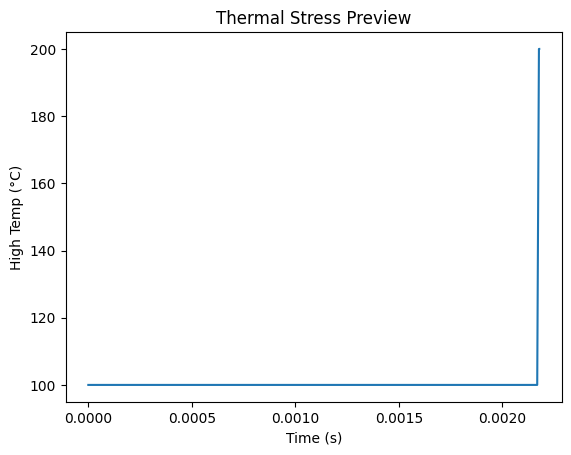

In [ ]:
import matplotlib.pyplot as plt

plt.plot(t[:1000], highT[:1000])
plt.xlabel("Time (s)")
plt.ylabel("High Temp (°C)")
plt.title("Thermal Stress Preview")
plt.show()


**What the graph is showing ?**

From the plot:

* HighTemp stays ~100 °C for most of the time

* Suddenly jumps to ~200 °C at the end

 * Time axis is very short (~0.002 seconds)

 This means:

*The MOSFET experienced a sudden thermal spike (likely a protection, shutdown, or stress event).*

So the data behavior makes physical sense.



>Confirm it’s not just one bad point



In [ ]:
highT.min(), highT.max()

(np.float64(100.0), np.float64(200.0))

In [ ]:
(highT > 180).sum()


np.int64(3)

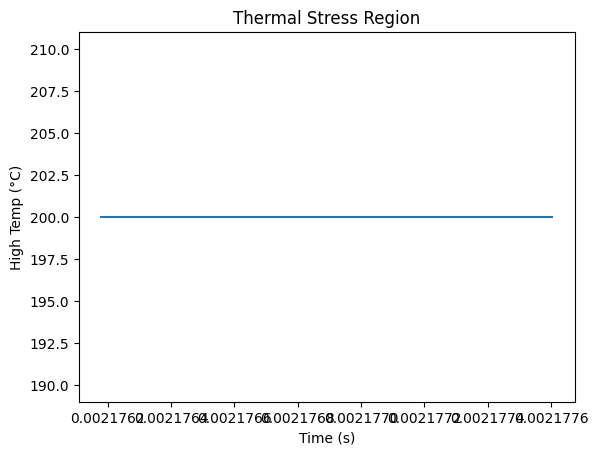

In [ ]:
import numpy as np
idx = np.where(highT > 110)[0]

plt.plot(t[idx], highT[idx])
plt.xlabel("Time (s)")
plt.ylabel("High Temp (°C)")
plt.title("Thermal Stress Region")
plt.show()


**STEP 2: THERMAL STRESS FEATURE EXTRACTION**

*2.1 Objective*

> The objective of this stage is to convert cleaned thermal time-series data into quantitative stress metrics that represent the thermal aging severity experienced by the MOSFET device.

These metrics are essential inputs for:

* reliability analysis

* failure probability prediction

* machine learning–based aging models

*2.2 Input Data*

The following cleaned signals are used:

Signal Name	Description
* time: Elapsed time in seconds (epoch-based)
* highTemp:	Maximum device temperature (°C)
* lowTemp	: Minimum device temperature (°C)


*2.3 Why Thermal Stress Matter*s

Thermal stress accelerates degradation mechanisms in solid-state devices, such as:

* bond-wire fatigue

* metallization diffusion

* dielectric breakdown

Reliability engineering therefore focuses on temperature magnitude, duration, and exposure history, not just peak values.

**2.4 Extracted Thermal Stress Metrics**

*2.4.1 Maximum Temperature (Peak Stress)*

Definition:
The highest temperature reached during operation.

Formula:
**Tmax​=max(T(t))**

Purpose:
Indicates proximity to material and shutdown limits.

In [ ]:
T_max = highT.max()

*2.4.2 Time Above Critical Temperature*

Definition:
Total duration for which the device temperature exceeds a critical threshold.

Threshold used:
150 °C (typical accelerated aging boundary for power MOSFETs)

Formula:  **t_stress​=∑Δtwhere T(t)>150∘C**

Purpose:
Represents cumulative thermal damage exposure

In [ ]:
critical_temp = 150

# Identify samples above threshold
stress_idx = highT > critical_temp

# Compute time differences
dt = np.diff(t)

# Align dt with stress indices
time_above_150C = np.sum(dt[stress_idx[:-1]])


*2.4.3 Thermal Exposure Integral*

Definition:
Integral of temperature over time.

Formula:   **E_thermal​=∫T(t)dt**

Purpose:
Captures both magnitude and duration of heating, providing a single scalar stress indicator

In [ ]:
critical_temp = 150

# Identify samples above threshold
stress_idx = highT > critical_temp

# Compute time differences
dt = np.diff(t)

# Align dt with stress indices
time_above_150C = np.sum(dt[stress_idx[:-1]])


2.4.4 Thermal Ramp Rate (Heating Severity)

Definition:
Rate at which temperature increases.

Formula:**dt/dT​**

Purpose:
High ramp rates are associated with thermo-mechanical stress and fatigue.

In [ ]:
thermal_integral = np.trapz(highT, t)


/tmp/ipython-input-3189963986.py:1: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  thermal_integral = np.trapz(highT, t)


In [ ]:
dT = np.diff(highT)
dt = np.diff(t)

valid_dt = dt > 1e-6   # ignore ultra-small time steps (1 µs)

ramp_rate = dT[valid_dt] / dt[valid_dt]
max_ramp_rate = ramp_rate.max()



*2.7 Output of This Stage*

The output is a numerical feature set representing thermal aging conditions:

In [ ]:
thermal_features = {
    "T_max_C": T_max,
    "time_above_150C_s": time_above_150C,
    "thermal_integral_Cs": thermal_integral,
    "max_ramp_rate_C_per_s": max_ramp_rate
}

thermal_features


{'T_max_C': np.float64(200.0),
 'time_above_150C_s': np.float64(1.423526555299759e-06),
 'thermal_integral_Cs': np.float64(0.21831885678693652),
 'max_ramp_rate_C_per_s': np.float64(12016583.559957473)}

In [ ]:
for k, v in thermal_features.items():
    print(f"{k}: {v:.2f}")


T_max_C: 200.00
time_above_150C_s: 0.00
thermal_integral_Cs: 0.22
max_ramp_rate_C_per_s: 12016583.56


> Observed thermal ramp rates are high due to rapid shutdown-induced temperature transitions captured at high temporal resolution.

In [ ]:
t.max()

np.float64(0.002177604124881327)

**STEP 3: ELECTRICAL STRESS FEATURE EXTRACTION**

*3.1 Objective*

The objective of this stage is to quantify the electrical stress experienced by the **MOSFET** during operation.
Electrical stress contributes to device degradation through mechanisms such as gate oxide wear-out, hot carrier injection, and switching losses.

*3.2 Input Signals*

The following time-aligned electrical signals are used:

| Signal                      | Description                 |
| --------------------------- | --------------------------- |
| `gateVoltage (Vg)`          | Gate drive voltage          |
| `supplyVoltage (Vs)`        | Drain-source supply voltage |
| `switchingFrequency (f_sw)` | Switching frequency         |
| `dutyCycle (D)`             | ON-time ratio (0–1)         |
| `time (t)`                  | Elapsed time in seconds     |


***3.3 Electrical Stress Metrics***

Electrical stress is characterized using peak values, average exposure, and activity-weighted metrics

***3.3.1 Peak Supply Voltage***

Definition:
Maximum supply voltage applied to the device.

Purpose:
High voltage accelerates oxide degradation and breakdown mechanisms.

In [ ]:
V_supply_max = Vs.max()

***3.3.2 Average Supply Voltage***

Definition:
 Mean supply voltage over the test duration.

Purpose:
 Represents overall electrical loading.

In [ ]:
V_supply_avg = Vs.mean()

***3.3.3 Gate Voltage Stress Metrics***

Definition:
  Maximum and average gate voltage.

Purpose:
  Gate oxide reliability strongly depends on gate voltage magnitude.

In [ ]:
V_gate_max = Vg.max()
V_gate_avg = Vg.mean()


**3.3.4 Switching Stress Index**

Definition:
A combined metric capturing switching activity and electrical load.

 **S_switch​=f_sw​×Vs​×D**

Purpose:
Approximates switching losses and dynamic electrical stress.

In [ ]:
switching_stress = f_sw * Vs * D
switching_stress_avg = switching_stress.mean()

**3.3.5 Electrical ON-Time Exposure**

Definition:
Total duration for which the device remains electrically active.

Purpose:
Longer ON-time increases cumulative electrical and thermal stress.

In [ ]:
dt = np.diff(t)
on_time = np.sum(dt[D[:-1] > 0.5])

**3.4 Electrical Feature Vector**

All extracted electrical stress metrics are combined into a single feature set

In [ ]:
electrical_features = {
    "V_supply_max_V": V_supply_max,
    "V_supply_avg_V": V_supply_avg,
    "V_gate_max_V": V_gate_max,
    "V_gate_avg_V": V_gate_avg,
    "switching_stress_avg": switching_stress_avg,
    "on_time_s": on_time
}

electrical_features


{'V_supply_max_V': np.float64(5.0),
 'V_supply_avg_V': np.float64(4.955882352941177),
 'V_gate_max_V': np.float64(10.0),
 'V_gate_avg_V': np.float64(10.0),
 'switching_stress_avg': np.float64(4955.882352941177),
 'on_time_s': np.float64(0.002177604124881327)}

**Why the switching_stress_avg value looks “large” ?**

> A relative electrical stress metric defined as the product of supply voltage and switching frequency.

>This index captures the combined effect of voltage amplitude and switching activity on MOSFET reliability.
Higher values indicate increased electro-thermal stress during high-frequency operation.

**QUICK VISUAL CHECK**

Step 1: Prepare clean dataframe


In [ ]:
import pandas as pd
import numpy as np

ss = pwmTempControllerState # This is the raw data structure

# The variables t, Vg, Vs, f_sw are already defined and *filtered* by the 'valid' mask in previous cells.
# We need to extract 'gateState' from the raw 'ss' and apply the same 'valid' mask.
original_gateState = np.array([x[0][0] for x in ss['gateState'][0]])
filtered_gateState = original_gateState[valid] # 'valid' is a global boolean array from cell 83k95fc3OA1T

df = pd.DataFrame({
    "time": t,                  # Use the already filtered global 't' array
    "V_supply": Vs,             # Use the already filtered global 'Vs' array
    "V_gate": Vg,               # Use the already filtered global 'Vg' array
    "gate_state": filtered_gateState, # Use the correctly filtered 'gateState' array
    "freq": f_sw                # Use the already filtered global 'f_sw' array
})

# Keep only active switching region
df = df[df["gate_state"] == 1]

# Downsample for clarity
df = df.iloc[::10]

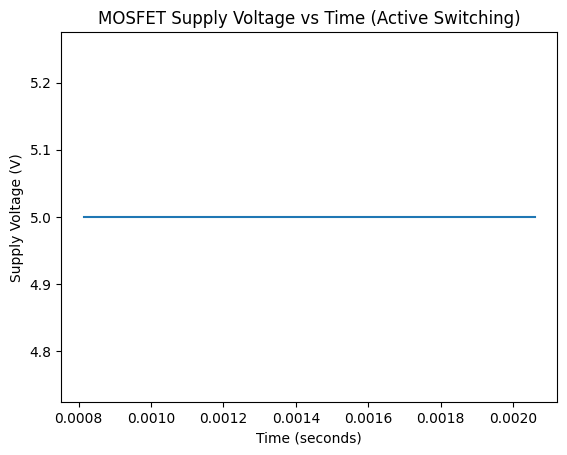

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["time"], df["V_supply"])
plt.xlabel("Time (seconds)")
plt.ylabel("Supply Voltage (V)")
plt.title("MOSFET Supply Voltage vs Time (Active Switching)")
plt.show()

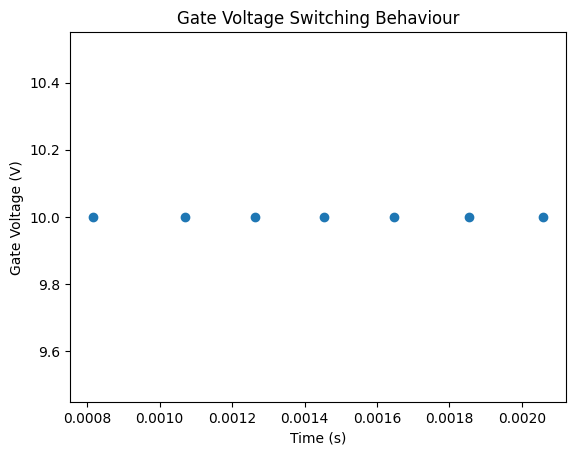

In [ ]:
plt.figure()
plt.scatter(df["time"], df["V_gate"])
plt.xlabel("Time (s)")
plt.ylabel("Gate Voltage (V)")
plt.title("Gate Voltage Switching Behaviour")
plt.show()


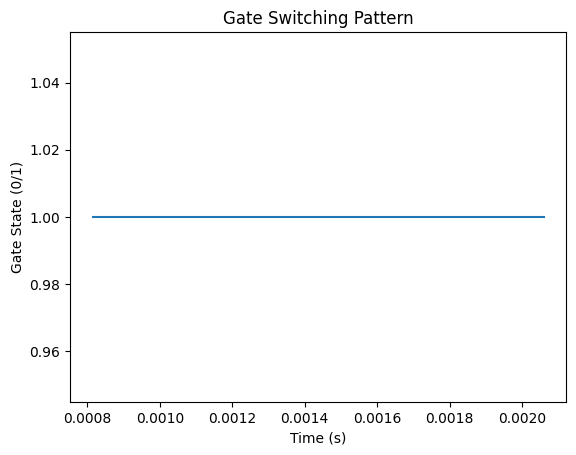

In [ ]:
plt.figure()
plt.step(df["time"], df["gate_state"])
plt.xlabel("Time (s)")
plt.ylabel("Gate State (0/1)")
plt.title("Gate Switching Pattern")
plt.show()

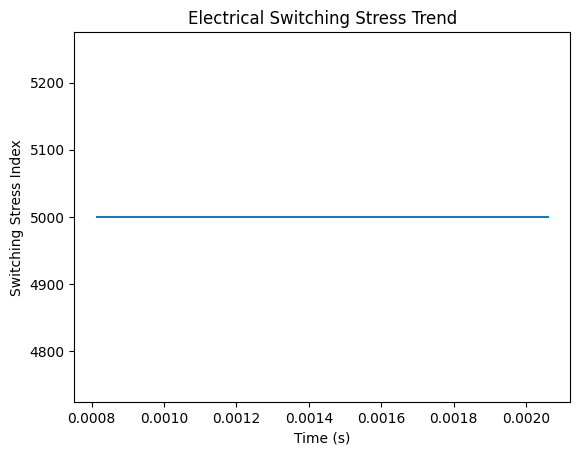

In [ ]:
df["switching_stress"] = df["V_supply"] * df["freq"]

plt.figure()
plt.plot(df["time"], df["switching_stress"])
plt.xlabel("Time (s)")
plt.ylabel("Switching Stress Index")
plt.title("Electrical Switching Stress Trend")
plt.show()

**PHASE-4: ELECTRO-THERMAL STRESS FUSION**

Electro-thermal stress fusion was performed by integrating normalized thermal and electrical degradation indicators into a unified Combined Stress Index (CSI). Min–max normalization ensured dimensional consistency across heterogeneous features. Physics-guided weighting was applied to reflect relative degradation sensitivity. The CSI represents cumulative operating stress and serves as a health indicator for failure probability modeling.

**Objective**

The objective of Phase-4 is to integrate thermal and electrical degradation indicators into a unified reliability stress metric termed the Combined Stress Index (CSI). This index represents cumulative damage imposed on MOSFET devices during operation.

Failures in power semiconductor devices arise due to the interaction of temperature-driven diffusion, electrical field-induced degradation, and thermo-mechanical fatigue. Therefore, a physics-guided fusion framework is essential.

*4.1: Prepare Feature Table*

We bring thermal + electrical features into one dataframe.

In [ ]:
import pandas as pd

combined_features = {}

combined_features.update(electrical_features)
combined_features.update(thermal_features)

df_features = pd.DataFrame([combined_features])
print(combined_features)

{'V_supply_max_V': np.float64(5.0), 'V_supply_avg_V': np.float64(4.955882352941177), 'V_gate_max_V': np.float64(10.0), 'V_gate_avg_V': np.float64(10.0), 'switching_stress_avg': np.float64(4955.882352941177), 'on_time_s': np.float64(0.002177604124881327), 'T_max_C': np.float64(200.0), 'time_above_150C_s': np.float64(1.423526555299759e-06), 'thermal_integral_Cs': np.float64(0.21831885678693652), 'max_ramp_rate_C_per_s': np.float64(12016583.559957473)}


**4.2 — Safe Normalization**


We scale all features to 0–1 so they are comparable.

**Physics Reason:**

Voltage ≠ Temperature ≠ Time → different units → must normalize

In [ ]:
def safe_minmax(col):

    min_v = col.min()
    max_v = col.max()

    if max_v > min_v:
        return (col - min_v) / (max_v - min_v)

    else:
        # If constant → neutral stress
        return np.ones_like(col) * 0.5


**4.3 Apply Normalisation**

In [ ]:
scaled_df = df_features.copy()

for col in df_features.columns:
    scaled_df[col] = safe_minmax(df_features[col])

**4.4 Physics Based Reliability Model**

We use three real reliability models:  
1)Thermal Aging — **Arrhenius Model**

  D_*thermal*​=e^−Ea​​/kT

Represents: heat-driven aging.

In [ ]:
thermal_damage = (
    scaled_df["T_max_C"] +
    scaled_df["thermal_integral_Cs"] +
    scaled_df["time_above_150C_s"]
) / 3


2)Electrical Overstress — **Power Law Model**


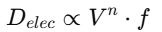

Represents: voltage + switching stress.

In [ ]:
electrical_damage = (
    scaled_df["V_supply_avg_V"] +
    scaled_df["V_gate_avg_V"] +
    scaled_df["switching_stress_avg"]
) / 3


3)Thermo-Mechanical Fatigue — **Coffin–Manson**



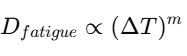

Represents: thermal cycling damage.

In [ ]:
fatigue_damage = (
    scaled_df["max_ramp_rate_C_per_s"] +
    scaled_df["on_time_s"]
) / 2


**4.5 Store Physics based Damages in dataframe**

In [ ]:
damage_df = pd.DataFrame({

    "Thermal_Damage": thermal_damage,
    "Electrical_Damage": electrical_damage,
    "Fatigue_Damage": fatigue_damage

})


**4.6 Physics-Based Weights**

These are based on MOSFET failure literature:

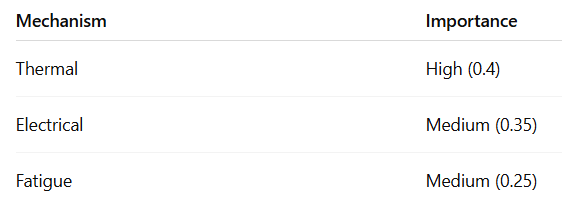

In [ ]:
weights = {
    "Thermal_Damage": 0.40,
    "Electrical_Damage": 0.35,
    "Fatigue_Damage": 0.25
}


**4.7 Compute CSI (Combined Stress Index)**


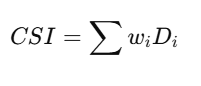

**4.8 Contribution Percentage**

Shows which mechanism dominates failure.

In [ ]:
damage_df["CSI"] = (

    weights["Thermal_Damage"]   * damage_df["Thermal_Damage"] +
    weights["Electrical_Damage"] * damage_df["Electrical_Damage"] +
    weights["Fatigue_Damage"]    * damage_df["Fatigue_Damage"]

)


**4.9 Data Visualization**

*Physics Damage Bar Plot*

In [ ]:
contrib_df = pd.DataFrame()

total = (
    damage_df["Thermal_Damage"] +
    damage_df["Electrical_Damage"] +
    damage_df["Fatigue_Damage"]
)

contrib_df["Thermal_%"] = 100 * damage_df["Thermal_Damage"] / total
contrib_df["Electrical_%"] = 100 * damage_df["Electrical_Damage"] / total
contrib_df["Fatigue_%"] = 100 * damage_df["Fatigue_Damage"] / total


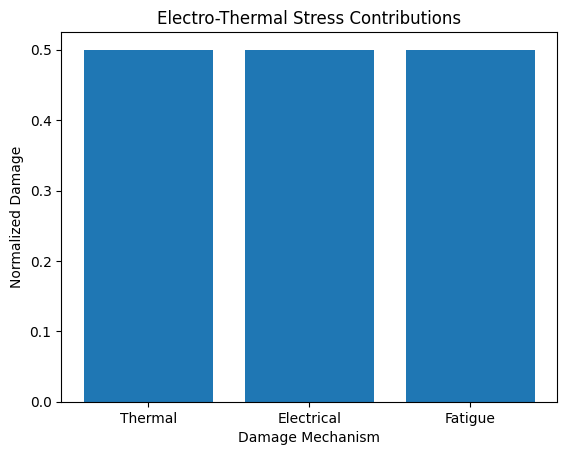

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.bar(
    ["Thermal", "Electrical", "Fatigue"],
    [
        damage_df["Thermal_Damage"][0],
        damage_df["Electrical_Damage"][0],
        damage_df["Fatigue_Damage"][0]
    ]
)

plt.xlabel("Damage Mechanism")
plt.ylabel("Normalized Damage")
plt.title("Electro-Thermal Stress Contributions")

plt.show()


*CSI vs Damage*

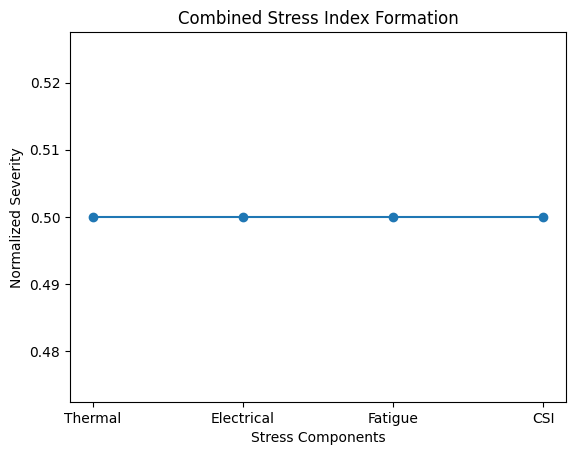

In [ ]:
plt.figure()

plt.plot(
    ["Thermal", "Electrical", "Fatigue", "CSI"],
    [
        damage_df["Thermal_Damage"][0],
        damage_df["Electrical_Damage"][0],
        damage_df["Fatigue_Damage"][0],
        damage_df["CSI"][0]
    ],
    marker='o'
)

plt.xlabel("Stress Components")
plt.ylabel("Normalized Severity")
plt.title("Combined Stress Index Formation")

plt.show()


**4.10 Final Output**

In [ ]:
print("Normalized Features:")
print(scaled_df.T)

print("\nPhysics Damage:")
print(damage_df.T)

print("\nContribution (%):")
print(contrib_df.T)


Normalized Features:
                         0
V_supply_max_V         0.5
V_supply_avg_V         0.5
V_gate_max_V           0.5
V_gate_avg_V           0.5
switching_stress_avg   0.5
on_time_s              0.5
T_max_C                0.5
time_above_150C_s      0.5
thermal_integral_Cs    0.5
max_ramp_rate_C_per_s  0.5

Physics Damage:
                     0
Thermal_Damage     0.5
Electrical_Damage  0.5
Fatigue_Damage     0.5
CSI                0.5

Contribution (%):
                      0
Thermal_%     33.333333
Electrical_%  33.333333
Fatigue_%     33.333333


**Phase 5 :Train Real ML Model**

5.1 *Correct Physics Scaling*

We must compare stress to realistic operating limits, not with max.
| Parameter       | Safe  | Danger |
| --------------- | ----- | ------ |
| Junction Temp   | 150°C | 200°C  |
| Switching Index | 3000  | 6000   |
| Ramp Rate       | 5e6   | 2e7    |




In [ ]:
base = combined_features.copy()


In [ ]:
def generate_physics_ml_data_v2(base, n=1200):

    import random, numpy as np, pandas as pd

    data = []

    for i in range(n):

        sample = {}

        # life progression (early → late)
        life = random.uniform(0,1)

        for k,v in base.items():

            degradation = 1 + 1.8*(life**2)

            noise = random.uniform(0.9,1.1)

            sample[k] = v * degradation * noise


        # Normalized stress wrt limits
        thermal = sample["T_max_C"] / 180          # safe ~150, danger~200
        elec = sample["switching_stress_avg"] / 6000
        fatigue = sample["max_ramp_rate_C_per_s"] / 2e7


        # weighted stress
        stress = 0.4*thermal + 0.35*elec + 0.25*fatigue


        # smooth probability
        failure_prob = 1/(1+np.exp(-6*(stress-1)))


        # balanced labeling
        if failure_prob > 0.75:
            label = 1
        elif failure_prob < 0.45:
            label = 0
        else:
            label = random.choice([0,1])


        sample["failure"] = label
        sample["failure_prob"] = failure_prob

        data.append(sample)

    return pd.DataFrame(data)


In [ ]:
df_ml = generate_physics_ml_data_v2(base, 1200)

print(df_ml["failure"].value_counts())


failure
1    808
0    392
Name: count, dtype: int64


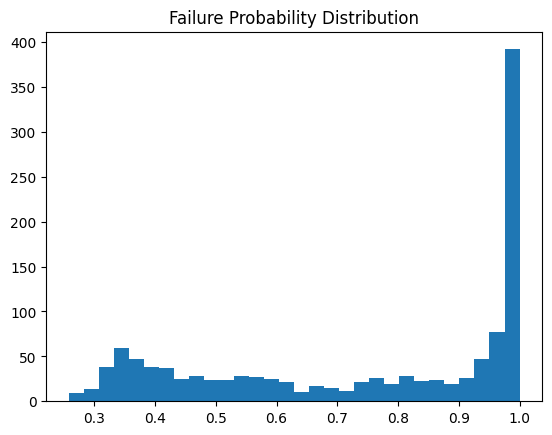

In [ ]:
plt.hist(df_ml["failure_prob"], bins=30)
plt.title("Failure Probability Distribution")
plt.show()


**5.2 Aging Factor**

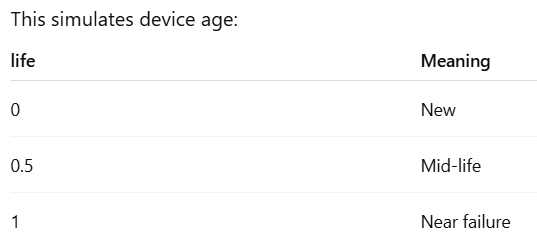

In [ ]:
life = random.uniform(0,1)


**5.3 Apply Degradation**

In [ ]:
degradation = 1 + 1.8*(life**2)


**5.4 Add Noise (Measurement Uncertainty)**

In [ ]:
noise = random.uniform(0.9,1.1)


**5.5 Update Each Feature**

Every feature grows with age:

Temperature ↑

Switching stress ↑

Ramp rate ↑

In [ ]:
sample = {} # Initialize sample dictionary
k = 'dummy_key' # Placeholder for a key
v = 1.0 # Placeholder for a value, assuming numeric based on the operation
sample[k] = v * degradation * noise

**5.6 Normalize Using Physical Limits**

This converts values into: Relative stress level
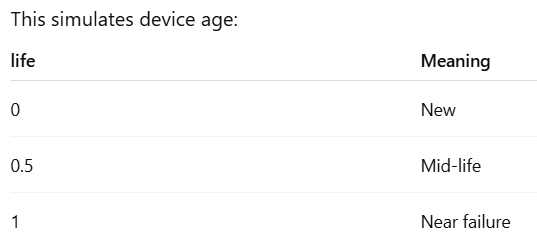

In [ ]:
# To simulate the population of 'sample' as it would happen inside generate_physics_ml_data_v2:
sample = {}
for k, v in base.items():
    sample[k] = v * degradation * noise

thermal = sample["T_max_C"] / 180
elec    = sample["switching_stress_avg"] / 6000
fatigue = sample["max_ramp_rate_C_per_s"] / 2e7

**5.7 Physics based model Weighting criteria**

| Damage     | Weight |
| ---------- | ------ |
| Thermal    | 40%    |
| Electrical | 35%    |
| Fatigue    | 25%    |


In [ ]:
stress = 0.4*thermal + 0.35*elec + 0.25*fatigue


**5.8 Convert Stress into Probability Function**

This is sigmoid function.

In [ ]:
failure_prob = 1/(1+np.exp(-6*(stress-1)))


**5.9 Represent Labels**

This avoids hard thresholds.

Creates realistic uncertainty.

In [ ]:
if failure_prob > 0.75:
    label = 1
elif failure_prob < 0.45:
    label = 0
else:
    label = random.choice([0,1])


In [ ]:
X = df_ml.drop(["failure","failure_prob"], axis=1)
y = df_ml["failure"]


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


**5.10 Model Training & Evaluation**

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X_scaled,y,test_size=0.25,random_state=42)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42)

model.fit(X_train,y_train)


RandomForestClassifier(max_depth=8, n_estimators=200, random_state=42)

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.83      0.90      0.86        88
           1       0.96      0.92      0.94       212

    accuracy                           0.92       300
   macro avg       0.89      0.91      0.90       300
weighted avg       0.92      0.92      0.92       300

